In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# CELL 1: Git Clone & Setup
import os
REPO_URL = "https://github.com/DanielQH07/tranSTR_Casual.git" 
REPO_NAME = "tranSTR_Casual"
BRANCH = "groundedDINO" 

if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_URL}...")
    !git clone {REPO_URL} -b {BRANCH}
else:
    print("Repo already exists.")

# Change Directory to the repo root 
if os.path.basename(os.getcwd()) != REPO_NAME:
    try:
        target_dir = os.path.join(os.getcwd(), REPO_NAME, "causalvid")
        if os.path.exists(target_dir):
             os.chdir(target_dir)
        elif os.path.exists(REPO_NAME):
             os.chdir(REPO_NAME)
        
        print(f"Changed directory to: {os.getcwd()}")
    except Exception as e:
             print(f"Could not set working directory: {e}")

Cloning https://github.com/DanielQH07/tranSTR_Casual.git...
Cloning into 'tranSTR_Casual'...
remote: Enumerating objects: 308, done.
remote: Counting objects: 100% (308/308), done.
remote: Compressing objects: 100% (209/209), done.
remote: Total 308 (delta 161), reused 241 (delta 94), pack-reused 0 (from 0)
Receiving objects: 100% (308/308), 21.58 MiB | 12.29 MiB/s, done.
Resolving deltas: 100% (161/161), done.
Changed directory to: /kaggle/working/tranSTR_Casual


In [ ]:
# CELL 2: Install & Login W&B (với API Key trực tiếp)
print('=== CELL 2: W&B Setup ===')
!pip install -q wandb peft --upgrade
import wandb

# ============================================
# WANDB CONFIG - THAY THẾ BẰNG API KEY CỦA BẠN
# ============================================
WANDB_API_KEY = ''  # 🔴 Paste your W&B API key here
WANDB_PROJECT = 'transtr-causalvid-dino-lora'   # Project name on W&B
WANDB_ENTITY = None                        # Your W&B username/team (None = default)

# Login with API key (no interactive prompt)
wandb.login(key=WANDB_API_KEY)
print('✅ W&B logged in successfully!')

=== CELL 2: W&B Setup ===
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 65.1 MB/s eta 0:00:00


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: haidang262004 (haidang262004-i-h-c-qu-c-gia-tp-hcm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B logged in successfully!


In [ ]:
# CELL 3: Imports
print('=== CELL 3: Imports ===')
import os, copy, math, torch, numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from utils.util import set_seed, set_gpu_devices
from DataLoader import VideoQADataset
from networks.model import VideoQAmodel
from transformers import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm
print('Imports OK')

=== CELL 3: Imports ===
Imports OK


In [ ]:
# CELL 4: Train/Eval functions (AMP + R-Drop + EMA + Feature Noise + Per-qtype + Cosine scheduler)
print('=== CELL 4: Functions ===')

import wandb  # ensure available at runtime

QFAMILY_NAMES = {
    0: 'descriptive',
    1: 'explanatory',
    2: 'predictive',
    3: 'predictive_reason',
    4: 'counterfactual',
    5: 'counterfactual_reason',
}


class EMA:
    """Exponential Moving Average of trainable parameters."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {n: p.detach().clone() for n, p in model.named_parameters() if p.requires_grad}
        self.backup = {}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n].mul_(self.decay).add_(p.detach(), alpha=1 - self.decay)

    @torch.no_grad()
    def apply(self, model):
        self.backup = {}
        for n, p in model.named_parameters():
            if n in self.shadow:
                self.backup[n] = p.detach().clone()
                p.data.copy_(self.shadow[n])

    @torch.no_grad()
    def restore(self, model):
        for n, p in model.named_parameters():
            if n in self.backup:
                p.data.copy_(self.backup[n])
        self.backup = {}


class EarlyStop:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -1.0
        self.bad = 0

    def step(self, value):
        if value > self.best + self.min_delta:
            self.best = value
            self.bad = 0
            return False
        self.bad += 1
        return self.bad >= self.patience


def _unpack_batch(batch):
    if len(batch) == 7:
        ff, of, q, a, ans_id, qns_key, q_family_id = batch
    elif len(batch) == 6:
        ff, of, q, a, ans_id, qns_key = batch
        q_family_id = None
    else:
        raise ValueError(f'Unexpected batch format with {len(batch)} elements')
    return ff, of, q, a, ans_id, qns_key, q_family_id


def _add_feature_noise(ff, of, std):
    """Add gaussian noise only on ROI features (first 1024 dims), leave bbox intact."""
    if std <= 0:
        return ff, of
    ff = ff + std * torch.randn_like(ff)
    if of.size(-1) > 4:
        roi_dim = of.size(-1) - 4
        noise = torch.zeros_like(of)
        noise[..., :roi_dim] = std * torch.randn_like(of[..., :roi_dim])
        of = of + noise
    else:
        of = of + std * torch.randn_like(of)
    return ff, of


def _forward_losses(model, ff, of, q, a, tgt, q_family_id, xe, bce,
                    lambda_verifier, lambda_knowledge):
    out = model(ff, of, q, a, return_aux=True, q_family_id=q_family_id)
    if isinstance(out, dict):
        logits = out['logits']
        verifier_logits = out.get('verifier_logits', logits)
        knowledge_logits = out.get('knowledge_score', None)
        fused_logits = out.get('fused_score', logits)
    else:
        logits = out
        verifier_logits = out
        knowledge_logits = None
        fused_logits = logits

    ce_loss = xe(logits, tgt)
    verifier_targets = F.one_hot(tgt, num_classes=logits.size(-1)).float()
    verifier_loss = bce(verifier_logits, verifier_targets)
    if knowledge_logits is not None:
        knowledge_loss = bce(knowledge_logits, verifier_targets)
    else:
        knowledge_loss = torch.zeros((), device=logits.device)

    loss = ce_loss + lambda_verifier * verifier_loss + lambda_knowledge * knowledge_loss
    return loss, ce_loss, verifier_loss, knowledge_loss, logits, fused_logits


def train_epoch(model, optimizer, scheduler, scaler, ema, loader, xe, bce, device, epoch,
                accumulation_steps=1, lambda_verifier=0.1, lambda_knowledge=0.05,
                lambda_rdrop=0.5, use_rdrop=True, feature_noise_std=0.01,
                amp_dtype=torch.bfloat16, grad_clip=1.0):
    """AMP + R-Drop + EMA + feature noise + per-qtype accuracy."""
    model.train()
    total_loss = total_ce = total_ver = total_know = total_rdrop = 0.0
    correct = total = 0
    qtype_correct = {k: 0 for k in QFAMILY_NAMES}
    qtype_total = {k: 0 for k in QFAMILY_NAMES}
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f'Epoch {epoch}', leave=False)
    for batch_idx, batch in enumerate(pbar):
        ff, of, q, a, ans_id, _, q_family_id = _unpack_batch(batch)
        ff, of, tgt = ff.to(device, non_blocking=True), of.to(device, non_blocking=True), ans_id.to(device, non_blocking=True)
        q_family_id = q_family_id.to(device) if q_family_id is not None else None

        # Feature-noise augmentation
        ff_in, of_in = _add_feature_noise(ff, of, feature_noise_std)

        with autocast('cuda', dtype=amp_dtype):
            loss1, ce1, ver1, know1, logits1, fused1 = _forward_losses(
                model, ff_in, of_in, q, a, tgt, q_family_id, xe, bce,
                lambda_verifier, lambda_knowledge)

            if use_rdrop:
                loss2, ce2, ver2, know2, logits2, _ = _forward_losses(
                    model, ff_in, of_in, q, a, tgt, q_family_id, xe, bce,
                    lambda_verifier, lambda_knowledge)
                # Symmetric KL for R-Drop
                p1 = F.log_softmax(logits1, dim=-1)
                p2 = F.log_softmax(logits2, dim=-1)
                rdrop = 0.5 * (F.kl_div(p1, p2.exp(), reduction='batchmean') +
                               F.kl_div(p2, p1.exp(), reduction='batchmean'))
                loss = 0.5 * (loss1 + loss2) + lambda_rdrop * rdrop
                ce_loss = 0.5 * (ce1 + ce2)
                verifier_loss = 0.5 * (ver1 + ver2)
                knowledge_loss = 0.5 * (know1 + know2)
                rdrop_val = rdrop.detach().float().item()
            else:
                loss = loss1
                ce_loss, verifier_loss, knowledge_loss = ce1, ver1, know1
                rdrop_val = 0.0

        loss_scaled = loss / accumulation_steps
        scaler.scale(loss_scaled).backward()

        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(loader):
            if grad_clip and grad_clip > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            if scheduler is not None:
                scheduler.step()
            if ema is not None:
                ema.update(model)

        # Accumulate metrics
        total_loss += loss.detach().float().item()
        total_ce += ce_loss.detach().float().item()
        total_ver += verifier_loss.detach().float().item()
        total_know += knowledge_loss.detach().float().item() if torch.is_tensor(knowledge_loss) else float(knowledge_loss)
        total_rdrop += rdrop_val

        preds = fused1.argmax(-1)
        correct_mask = (preds == tgt)
        correct += correct_mask.sum().item()
        total += tgt.size(0)

        if q_family_id is not None:
            qf_cpu = q_family_id.detach().cpu()
            cm_cpu = correct_mask.detach().cpu()
            for k in QFAMILY_NAMES:
                m = (qf_cpu == k)
                if m.any():
                    qtype_total[k] += int(m.sum().item())
                    qtype_correct[k] += int(cm_cpu[m].sum().item())

        pbar.set_postfix({
            'loss': total_loss / (batch_idx + 1),
            'ce': total_ce / (batch_idx + 1),
            'rdrop': total_rdrop / (batch_idx + 1),
            'acc': correct / total * 100,
            'lr': optimizer.param_groups[0]['lr'],
        })

        if batch_idx % 50 == 0:
            wandb.log({
                'batch_total_loss': loss.detach().float().item(),
                'batch_ce_loss': ce_loss.detach().float().item(),
                'batch_verifier_loss': verifier_loss.detach().float().item(),
                'batch_knowledge_loss': knowledge_loss.detach().float().item() if torch.is_tensor(knowledge_loss) else 0.0,
                'batch_rdrop': rdrop_val,
                'batch_acc': correct_mask.float().mean().item() * 100,
                'lr_non_text': optimizer.param_groups[0]['lr'],
                'lr_lora': optimizer.param_groups[1]['lr'] if len(optimizer.param_groups) > 1 else 0.0,
                'batch': epoch * len(loader) + batch_idx,
            })

    n = len(loader)
    qtype_acc = {QFAMILY_NAMES[k]: (qtype_correct[k] / qtype_total[k] * 100 if qtype_total[k] else 0.0)
                 for k in QFAMILY_NAMES}
    return {
        'loss': total_loss / n,
        'ce': total_ce / n,
        'verifier': total_ver / n,
        'knowledge': total_know / n,
        'rdrop': total_rdrop / n,
        'train_acc': correct / total * 100,
        'qtype_acc': qtype_acc,
    }


@torch.no_grad()
def eval_epoch(model, loader, device, amp_dtype=torch.bfloat16, collect_qtype=True):
    model.eval()
    correct = total = 0
    qtype_correct = {k: 0 for k in QFAMILY_NAMES}
    qtype_total = {k: 0 for k in QFAMILY_NAMES}
    for batch in loader:
        ff, of, q, a, ans_id, _, q_family_id = _unpack_batch(batch)
        q_family_id = q_family_id.to(device) if q_family_id is not None else None
        tgt = ans_id.to(device)
        with autocast('cuda', dtype=amp_dtype):
            out = model(ff.to(device), of.to(device), q, a, return_aux=True, q_family_id=q_family_id)
        logits = out['fused_score'] if isinstance(out, dict) and 'fused_score' in out else (out['logits'] if isinstance(out, dict) else out)
        preds = logits.argmax(-1)
        cm = (preds == tgt)
        correct += cm.sum().item()
        total += tgt.size(0)
        if collect_qtype and q_family_id is not None:
            qf = q_family_id.detach().cpu()
            cmc = cm.detach().cpu()
            for k in QFAMILY_NAMES:
                m = (qf == k)
                if m.any():
                    qtype_total[k] += int(m.sum().item())
                    qtype_correct[k] += int(cmc[m].sum().item())
    qtype_acc = {QFAMILY_NAMES[k]: (qtype_correct[k] / qtype_total[k] * 100 if qtype_total[k] else 0.0)
                 for k in QFAMILY_NAMES}
    return correct / total * 100, qtype_acc


print('Functions defined: AMP + R-Drop + EMA + Feature Noise + Per-qtype logging!')

=== CELL 4: Functions ===
Functions defined with W&B logging!


In [6]:
# Merge CLIP Features (train/test/valid -> merged folder)
import os
import shutil
from tqdm.auto import tqdm

# ============================================
# 🔴 UPDATE THESE PATHS
# ============================================
CLIP_SPLIT_PATH = '/kaggle/input/datasets/danielq07/dinov3-feat/features'  # Folder chứa train/test/valid
CLIP_MERGED_PATH = '/kaggle/working/dinov3_T16_dim1024_merge'          # Folder output đã gộp

# Check structure
print(f'\nSource: {CLIP_SPLIT_PATH}')
if os.path.exists(CLIP_SPLIT_PATH):
    subfolders = os.listdir(CLIP_SPLIT_PATH)
    print(f'Subfolders found: {subfolders}')
else:
    print('❌ Source path not found!')
    subfolders = []

# Merge folders
os.makedirs(CLIP_MERGED_PATH, exist_ok=True)

total_copied = 0
for split in ['train', 'test', 'valid', 'val']:  # Try common folder names
    split_folder = os.path.join(CLIP_SPLIT_PATH, split)
    if not os.path.exists(split_folder):
        continue
    
    pt_files = [f for f in os.listdir(split_folder) if f.endswith('.pt')]
    print(f'\n📁 {split}: {len(pt_files)} files')
    
    for fname in tqdm(pt_files, desc=f'Copying {split}'):
        src = os.path.join(split_folder, fname)
        dst = os.path.join(CLIP_MERGED_PATH, fname)
        
        # Skip if already exists
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            total_copied += 1

# Summary
final_count = len([f for f in os.listdir(CLIP_MERGED_PATH) if f.endswith('.pt')])
print(f'\n✅ Merge complete!')
print(f'   Total .pt files in merged folder: {final_count}')
print(f'   Merged path: {CLIP_MERGED_PATH}')


Source: /kaggle/input/datasets/danielq07/dinov3-feat/features
Subfolders found: ['valid', 'test', 'train']

📁 train: 18776 files


Copying train:   0%|          | 0/18776 [00:00<?, ?it/s]


📁 test: 5429 files


Copying test:   0%|          | 0/5429 [00:00<?, ?it/s]


📁 valid: 2695 files


Copying valid:   0%|          | 0/2695 [00:00<?, ?it/s]


✅ Merge complete!
   Total .pt files in merged folder: 26900
   Merged path: /kaggle/working/dinov3_T16_dim1024_merge


In [ ]:
# CELL 5: Setup Paths & Config (Anti-overfit v4)
print('=== CELL 5: Paths & Config ===')

# ============================================
# KAGGLE INPUT PATHS - UPDATE THESE!
# ============================================
CLIP_FEATURE_PATH = CLIP_MERGED_PATH
GDINO_FEATURE_PATH = '/kaggle/input/datasets/danielq07/gdino-roi-all-nodes-merged'
ANNOTATION_PATH = '/kaggle/input/text-annotation/QA'
SPLIT_DIR = '/kaggle/input/casual-vid-data-split/split'

# Working directories
BASE = '/kaggle/working'
MODEL_DIR = os.path.join(BASE, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Verify paths
print('\n--- Path Verification ---')
def verify_path(name, path):
    if os.path.exists(path):
        items = os.listdir(path)[:3]
        print(f'OK  {name}: {items}')
        return True
    else:
        print(f'MISS {name}: NOT FOUND - {path}')
        return False

all_ok = True
all_ok &= verify_path('DINOv3 Features (1024D)', CLIP_FEATURE_PATH)
all_ok &= verify_path('GroundingDINO ROI Features', GDINO_FEATURE_PATH)
all_ok &= verify_path('Annotations', ANNOTATION_PATH)
all_ok &= verify_path('Splits', SPLIT_DIR)

if not all_ok:
    print('\nWARN: Please update paths above!')

# ============================================
# CONFIG v4 - Anti-overfit stack
# ============================================
RUN_TRAINING = True
MODEL_FILENAME = 'best_model_gdino_roi.ckpt'

FEAT_DIM = 1024  # DINOv3 frame features
print(f'\nBackbone: DINOv3 (D={FEAT_DIM}) + GroundingDINO ROI')

class Config:
    # Paths
    video_feature_root = CLIP_FEATURE_PATH
    grounding_dino_path = GDINO_FEATURE_PATH
    sample_list_path = ANNOTATION_PATH
    split_dir_txt = SPLIT_DIR

    # Model architecture
    topK_frame = 16
    objs = 20
    frames = 16
    select_frames = 5
    topK_obj = 12

    frame_feat_dim = FEAT_DIM
    obj_feat_dim = 1028
    use_grounding_dino = True

    d_model = 768
    word_dim = 768
    nheads = 8
    num_encoder_layers = 2
    num_decoder_layers = 2
    normalize_before = True
    activation = 'gelu'
    dropout = 0.3
    encoder_dropout = 0.3

    # Text encoder + LoRA (scaled up)
    text_encoder_type = 'microsoft/deberta-v3-base'
    freeze_text_encoder = False
    text_encoder_lr = 1e-5
    text_pool_mode = 1
    use_lora = True
    lora_r = 16                 # 8 -> 16 (capacity)
    lora_alpha = 32             # 16 -> 32 (keep alpha/r=2)
    lora_dropout = 0.15         # 0.1 -> 0.15
    lora_target_modules = ['query_proj', 'key_proj', 'value_proj']
    lora_lr = 5e-5              # 1e-4 -> 5e-5 (lower to avoid LoRA overfit)

    # Training (v4)
    bs = 8
    accumulation_steps = 4       # effective_bs = 32
    lr = 1e-5
    epoch = 15                   # 5 -> 15 (early stop will cut if plateaued)
    gpu = 0
    decay = 1e-2                 # 1e-4 -> 1e-2 (AdamW decoupled)
    n_query = 5
    lambda_verifier = 0.1        # 0.3 -> 0.1 (avoid reinforcing CE target)
    lambda_knowledge = 0.05      # 0.2 -> 0.05
    return_family_id = True

    # New anti-overfit knobs
    label_smoothing = 0.1
    warmup_ratio = 0.05          # cosine + linear warmup
    lambda_rdrop = 0.5           # R-Drop KL weight
    use_rdrop = True             # set False to halve train cost
    ema_decay = 0.999
    early_stop_patience = 3
    feature_noise_std = 0.01
    amp_dtype = 'bfloat16'       # 'bfloat16' or 'float16'
    grad_clip = 1.0

    # Other
    hard_eval = False
    pos_ratio = 1.0
    neg_ratio = 1.0
    a = 1.0
    num_workers = 4

args = Config()
if args.use_lora and args.freeze_text_encoder:
    raise ValueError('freeze_text_encoder khong the bat cung use_lora')

set_gpu_devices(args.gpu)
set_seed(999)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DTYPE = torch.bfloat16 if args.amp_dtype == 'bfloat16' else torch.float16

print(f'\nDevice: {device}')
print(f'Config: frame_feat_dim={args.frame_feat_dim}, obj_feat_dim={args.obj_feat_dim}')
print(f'Using GroundingDINO ROI features: {args.use_grounding_dino}')
print(f'Grad accum: bs={args.bs} x {args.accumulation_steps} = effective_bs={args.bs * args.accumulation_steps}')
print(f'Loss: CE(ls={args.label_smoothing}) + {args.lambda_verifier}*ver + {args.lambda_knowledge}*know + {args.lambda_rdrop}*rdrop(R-Drop={args.use_rdrop})')
print(f'LoRA: r={args.lora_r}, alpha={args.lora_alpha}, dropout={args.lora_dropout}, lr={args.lora_lr}')
print(f'Regularizers: EMA={args.ema_decay} | feature_noise_std={args.feature_noise_std} | weight_decay={args.decay}')
print(f'Schedule: cosine + warmup_ratio={args.warmup_ratio} | early_stop_patience={args.early_stop_patience}')
print(f'AMP: {args.amp_dtype}')

=== CELL 5: Paths & Config ===

--- Path Verification ---
✅ DINOv3 Features (1024D): ['9q8zoFUvTiw_000131_000141.pt', 'zWCcZVG7DkM_000093_000103.pt', 'P8Burl3aYGA_000001_000011.pt']
✅ GroundingDINO ROI Features: ['YEI7nmkbgQA_000040_000050.pkl', 'E5y8S1dOfkQ_000003_000013.pkl', 'dtgFHqPHnCo_000050_000060.pkl']
✅ Annotations: ['P-JmNb-FcLk_000041_000051', '2VBmRPrfNZY_000000_000010', '_muKn2ZeLK0_000018_000028']
✅ Splits: ['valid.pkl', 'train.pkl', 'test.pkl']

🔧 Backbone: DINOv3 (D=1024) + GroundingDINO ROI

Device: cuda
Config: frame_feat_dim=1024, obj_feat_dim=1028
Using GroundingDINO ROI features: True


In [ ]:
# CELL 6: Create Datasets
print('=== CELL 6: Datasets ===')

MAX_TRAIN_SAMPLES = None  # Change to None for all samples

print('\n--- Creating TRAIN dataset ---')
train_ds = VideoQADataset(
    split='train', n_query=args.n_query, obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    grounding_dino_path=args.grounding_dino_path,
    split_dir=args.split_dir_txt, topK_frame=args.topK_frame,
    max_samples=MAX_TRAIN_SAMPLES, verbose=True,
    return_family_id=args.return_family_id
)

print('\n--- Creating VAL dataset ---')
val_ds = VideoQADataset(
    split='val', n_query=args.n_query, obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    grounding_dino_path=args.grounding_dino_path,
    split_dir=args.split_dir_txt, topK_frame=args.topK_frame,
    max_samples=None, verbose=True,
    return_family_id=args.return_family_id
)

print('\n--- Creating TEST dataset ---')
test_ds = VideoQADataset(
    split='test', n_query=args.n_query, obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    grounding_dino_path=args.grounding_dino_path,
    split_dir=args.split_dir_txt, topK_frame=args.topK_frame,
    max_samples=None, verbose=True,
    return_family_id=args.return_family_id
)

train_loader = DataLoader(train_ds, args.bs, shuffle=True, num_workers=args.num_workers, pin_memory=True)
val_loader = DataLoader(val_ds, args.bs, shuffle=False, num_workers=args.num_workers, pin_memory=True)
test_loader = DataLoader(test_ds, args.bs, shuffle=False, num_workers=args.num_workers, pin_memory=True)

print('\n' + '='*60)
print('DATASET SUMMARY')
print('='*60)
print(f'Train: {len(train_ds)} samples -> {len(train_loader)} batches')
print(f'Val:   {len(val_ds)} samples -> {len(val_loader)} batches')
print(f'Test:  {len(test_ds)} samples -> {len(test_loader)} batches')
print(f'Frame feat dim: {args.frame_feat_dim} (DINOv3)')
print(f'Object feat dim: {args.obj_feat_dim} (GroundingDINO ROI + bbox)')
print(f'Return family id: {args.return_family_id}')
print('='*60)

=== CELL 6: Datasets ===

--- Creating TRAIN dataset ---
[train] Object feature format: unknown
[train] Using GroundingDINO features
[train] Indexed 26884 object features, 26900 ViT features
[train] Loaded 18776 video IDs from /kaggle/input/casual-vid-data-split/split/train.pkl
[train] ViT: 18776, Obj: 18765, Both: 18765


[train] Parsing annotations:   0%|          | 0/18765 [00:00<?, ?it/s]

[train] Final: 112590 QA pairs

--- Creating VAL dataset ---
[val] Object feature format: unknown
[val] Using GroundingDINO features
[val] Indexed 26884 object features, 26900 ViT features
[val] Loaded 2695 video IDs from /kaggle/input/casual-vid-data-split/split/valid.pkl
[val] ViT: 2695, Obj: 2693, Both: 2693


[val] Parsing annotations:   0%|          | 0/2693 [00:00<?, ?it/s]

[val] Final: 16158 QA pairs

--- Creating TEST dataset ---
[test] Object feature format: unknown
[test] Using GroundingDINO features
[test] Indexed 26884 object features, 26900 ViT features
[test] Loaded 5429 video IDs from /kaggle/input/casual-vid-data-split/split/test.pkl
[test] ViT: 5429, Obj: 5426, Both: 5426


[test] Parsing annotations:   0%|          | 0/5426 [00:00<?, ?it/s]

[test] Final: 32556 QA pairs

DATASET SUMMARY
Train: 112590 samples -> 14074 batches
Val:   16158 samples -> 2020 batches
Test:  32556 samples -> 4070 batches
Frame feat dim: 1024 (DINOv3)
Object feat dim: 1028 (GroundingDINO ROI + bbox)


In [ ]:
# CELL 7: Model + Optimizer + Cosine Scheduler + EMA + GradScaler (v4)
print('=== CELL 7: Model ===')

cfg = {k: v for k, v in Config.__dict__.items() if not k.startswith('_')}
cfg['device'] = device
cfg['topK_frame'] = args.select_frames

print(f'Creating model with frame_feat_dim = {cfg["frame_feat_dim"]}')
args.text_encoder_type = 'microsoft/deberta-v3-base'

model = VideoQAmodel(**cfg)
model.to(device)

# Param groups: non-text | LoRA | text encoder base
non_text_params, lora_params, text_base_params = [], [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if 'text_encoder' not in name:
        non_text_params.append(p)
    elif 'lora_' in name:
        lora_params.append(p)
    else:
        text_base_params.append(p)

param_groups = [
    {'params': non_text_params, 'lr': args.lr, 'weight_decay': args.decay},
    {'params': lora_params,     'lr': args.lora_lr, 'weight_decay': args.decay},
]
if len(text_base_params) > 0 and not args.freeze_text_encoder:
    param_groups.append({
        'params': text_base_params,
        'lr': args.text_encoder_lr,
        'weight_decay': args.decay,
    })
optimizer = torch.optim.AdamW(param_groups, betas=(0.9, 0.999))

# --- Cosine schedule with linear warmup (per optimizer.step) ---
# Effective steps per epoch = ceil(len(train_loader) / accumulation_steps) approx (+ final partial step)
steps_per_epoch = (len(train_loader) + args.accumulation_steps - 1) // args.accumulation_steps
total_steps = steps_per_epoch * args.epoch
warmup_steps = max(1, int(args.warmup_ratio * total_steps))
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
print(f'Scheduler: cosine w/ warmup {warmup_steps} / total {total_steps} steps ({steps_per_epoch} steps/epoch)')

# --- Losses (label smoothing CE) ---
xe = nn.CrossEntropyLoss(label_smoothing=args.label_smoothing)
bce = nn.BCEWithLogitsLoss()

# --- EMA + GradScaler ---
ema = EMA(model, decay=args.ema_decay)
# GradScaler is a no-op for bfloat16 but harmless; keep for fp16 path.
scaler = GradScaler('cuda', enabled=(AMP_DTYPE == torch.float16))

# Artifact names
BEST_ARTIFACT_NAME = 'best-model-dinov3'
LAST_ARTIFACT_NAME = 'last-checkpoint-dinov3'

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_text_params = sum(p.numel() for n, p in model.named_parameters() if 'text_encoder' in n and p.requires_grad)
print(f'Total params:    {total_params/1e6:.1f}M')
print(f'Trainable:       {trainable_params/1e6:.1f}M')
print(f'Trainable text:  {trainable_text_params/1e6:.3f}M')
print(f'LoRA params:     {sum(p.numel() for p in lora_params)/1e6:.3f}M')
print(f'Text-base params: {sum(p.numel() for p in text_base_params)/1e6:.3f}M')
print(f'EMA tracking:    {len(ema.shadow)} tensors')

=== CELL 7: Model ===
Creating model with frame_feat_dim = 1024


config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

2026-04-09 14:05:39.334313: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775743539.517592      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775743539.572479      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775743539.994160      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775743539.994202      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775743539.994205      23 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

Total params: 214.8M
Trainable:    214.8M


In [ ]:
# CELL 8.5: Resume Training from W&B Artifact (Optional)
print('=== CELL 8.5: Resume Training ===')

RESUME_FROM_CHECKPOINT = False
RESUME_ARTIFACT_ALIAS = 'latest'  # example: 'latest' or 'epoch-3'

start_epoch = 1
best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

if RESUME_FROM_CHECKPOINT:
    try:
        api = wandb.Api()
        resume_entity = WANDB_ENTITY or api.default_entity
        artifact_path = f'{resume_entity}/{WANDB_PROJECT}/{LAST_ARTIFACT_NAME}:{RESUME_ARTIFACT_ALIAS}'
        print(f'Downloading artifact: {artifact_path}')

        artifact = api.artifact(artifact_path)
        artifact_dir = artifact.download()
        checkpoint_path = os.path.join(artifact_dir, 'last_checkpoint.ckpt')

        checkpoint = torch.load(checkpoint_path, map_location=device)

        # strict=False to support loading checkpoints from before verifier head exists
        missing, unexpected = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        if missing:
            print(f'⚠️ Missing keys (expected when architecture changed): {len(missing)}')
        if unexpected:
            print(f'⚠️ Unexpected keys: {len(unexpected)}')

        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        start_epoch = checkpoint['epoch'] + 1
        best_acc = checkpoint['best_acc']
        history = checkpoint['history']

        print(f'✅ Checkpoint loaded from epoch {checkpoint["epoch"]}')
        print(f'📌 Resuming from epoch {start_epoch}')
        print(f'📌 Best accuracy so far: {best_acc:.2f}%')
        print(f'📌 Training history: {len(history["train_loss"])} epochs')

    except Exception as e:
        print(f'⚠️ Could not resume from W&B artifact: {e}')
        print('Starting from scratch...')
else:
    print('Starting fresh training (RESUME_FROM_CHECKPOINT=False)')

print(f'Start epoch: {start_epoch}')

In [ ]:
# CELL 8: Initialize W&B Run
print('=== CELL 8: Initialize W&B Run ===')

# Create W&B config dict
wandb_config = {
    'model': 'TranSTR',
    'backbone': 'DINOv3_T16_dim1024',
    'object_features': 'GroundingDINO_ROI',
    'frame_feat_dim': args.frame_feat_dim,
    'obj_feat_dim': args.obj_feat_dim,
    'use_grounding_dino': args.use_grounding_dino,
    'text_encoder': args.text_encoder_type,
    'use_lora': args.use_lora,
    'lora_r': args.lora_r,
    'lora_alpha': args.lora_alpha,
    'lora_dropout': args.lora_dropout,
    'lora_target_modules': args.lora_target_modules,
    'lora_lr': args.lora_lr,
    'batch_size': args.bs,
    'accumulation_steps': args.accumulation_steps,
    'effective_batch_size': args.bs * args.accumulation_steps,
    'learning_rate': args.lr,
    'text_encoder_lr': args.text_encoder_lr,
    'epochs': args.epoch,
    'max_train_samples': MAX_TRAIN_SAMPLES,
    'd_model': args.d_model,
    'nheads': args.nheads,
    'num_encoder_layers': args.num_encoder_layers,
    'num_decoder_layers': args.num_decoder_layers,
    'dropout': args.dropout,
    'topK_frame': args.select_frames,
    'topK_obj': args.topK_obj,
    'lambda_verifier': args.lambda_verifier,
    'lambda_knowledge': args.lambda_knowledge,
    'return_family_id': args.return_family_id,
    'train_samples': len(train_ds),
    'val_samples': len(val_ds),
    'test_samples': len(test_ds),
}

# Initialize W&B run
run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    config=wandb_config,
    name=f'transtr-gdino-roi-lora{int(args.use_lora)}-ep{args.epoch}-bs{args.bs}x{args.accumulation_steps}-ver{args.lambda_verifier}-know{args.lambda_knowledge}',
    reinit=True
)

# Watch model for gradient logging
wandb.watch(model, log='gradients', log_freq=100)

print(f'✅ W&B Run initialized: {run.url}')
print(f'📊 Effective batch size: {args.bs} × {args.accumulation_steps} = {args.bs * args.accumulation_steps}')
print(f'🧪 Verifier lambda: {args.lambda_verifier}')
print(f'🧠 Knowledge lambda: {args.lambda_knowledge}')
print(f'🧩 LoRA: {args.use_lora} | target={args.lora_target_modules}')

=== CELL 8: Initialize W&B Run ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/tranSTR_Casual/wandb/run-20260409_140601-8b1xffkp
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run transtr-gdino-roi-ep5-bs8
wandb: ⭐️ View project at https://wandb.ai/haidang262004-i-h-c-qu-c-gia-tp-hcm/transtr-causalvid-dino
wandb: 🚀 View run at https://wandb.ai/haidang262004-i-h-c-qu-c-gia-tp-hcm/transtr-causalvid-dino/runs/8b1xffkp


✅ W&B Run initialized: https://wandb.ai/haidang262004-i-h-c-qu-c-gia-tp-hcm/transtr-causalvid-dino/runs/8b1xffkp


In [ ]:
# CELL 9: Training v4 (AMP + R-Drop + EMA + Early Stop + Per-qtype + Artifact)
print('=== CELL 9: Training v4 ===')

import tempfile, shutil

BEST_LOCAL_CKPT = os.path.join(MODEL_DIR, MODEL_FILENAME)
early_stopper = EarlyStop(patience=args.early_stop_patience)
early_stopper.best = best_acc  # resume-aware
ep = start_epoch - 1  # in case loop doesn't execute

if RUN_TRAINING:
    for ep in range(start_epoch, args.epoch + 1):
        print(f'\nEpoch {ep}/{args.epoch}')

        train_stats = train_epoch(
            model, optimizer, scheduler, scaler, ema,
            train_loader, xe, bce, device, ep,
            accumulation_steps=args.accumulation_steps,
            lambda_verifier=args.lambda_verifier,
            lambda_knowledge=args.lambda_knowledge,
            lambda_rdrop=args.lambda_rdrop,
            use_rdrop=args.use_rdrop,
            feature_noise_std=args.feature_noise_std,
            amp_dtype=AMP_DTYPE,
            grad_clip=args.grad_clip,
        )
        loss = train_stats['loss']
        ce_loss = train_stats['ce']
        verifier_loss = train_stats['verifier']
        knowledge_loss = train_stats['knowledge']
        rdrop_loss = train_stats['rdrop']
        train_acc = train_stats['train_acc']

        # --- Validation: raw model ---
        val_acc, val_qtype = eval_epoch(model, val_loader, device, amp_dtype=AMP_DTYPE)

        # --- Validation: EMA weights ---
        ema.apply(model)
        val_acc_ema, val_qtype_ema = eval_epoch(model, val_loader, device, amp_dtype=AMP_DTYPE)
        ema.restore(model)

        # Pick best eval arm
        if val_acc_ema >= val_acc:
            best_val = val_acc_ema
            best_qtype = val_qtype_ema
            best_is_ema = True
        else:
            best_val = val_acc
            best_qtype = val_qtype
            best_is_ema = False

        gen_gap = train_acc - best_val

        history['train_loss'].append(loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(best_val)

        wandb_epoch = {
            'epoch': ep,
            'train_total_loss': loss,
            'train_ce_loss': ce_loss,
            'train_verifier_loss': verifier_loss,
            'train_knowledge_loss': knowledge_loss,
            'train_rdrop_loss': rdrop_loss,
            'train_acc': train_acc,
            'val_acc_raw': val_acc,
            'val_acc_ema': val_acc_ema,
            'val_acc': best_val,
            'val_is_ema': int(best_is_ema),
            'gen_gap': gen_gap,
            'lr_non_text': optimizer.param_groups[0]['lr'],
            'lr_lora': optimizer.param_groups[1]['lr'] if len(optimizer.param_groups) > 1 else 0.0,
            'best_val_acc': max(best_acc, best_val),
            'effective_batch_size': args.bs * args.accumulation_steps,
            'lambda_verifier': args.lambda_verifier,
            'lambda_knowledge': args.lambda_knowledge,
            'lambda_rdrop': args.lambda_rdrop,
        }
        for k, v in train_stats['qtype_acc'].items():
            wandb_epoch[f'train_qtype/{k}'] = v
        for k, v in best_qtype.items():
            wandb_epoch[f'val_qtype/{k}'] = v
        wandb.log(wandb_epoch)

        print(
            f'Total: {loss:.4f} | CE: {ce_loss:.4f} | Ver: {verifier_loss:.4f} '
            f'| Know: {knowledge_loss:.4f} | RDrop: {rdrop_loss:.4f} '
            f'| Train: {train_acc:.1f}% | Val(raw): {val_acc:.1f}% | Val(EMA): {val_acc_ema:.1f}% '
            f'| Gap: {gen_gap:.1f}%'
        )
        print('  per-qtype val: ' + ' | '.join(f'{k[:4]}={v:.1f}' for k, v in best_qtype.items()))

        # --- Save best artifact (use EMA weights if they win) ---
        if best_val > best_acc:
            best_acc = best_val
            with tempfile.NamedTemporaryFile(suffix='.ckpt', delete=False) as tmp_best:
                best_tmp_path = tmp_best.name
            if best_is_ema:
                ema.apply(model)
                torch.save(model.state_dict(), best_tmp_path)
                ema.restore(model)
            else:
                torch.save(model.state_dict(), best_tmp_path)

            # Keep a LOCAL copy so Cell 10 (eval) can reload best weights
            shutil.copy(best_tmp_path, BEST_LOCAL_CKPT)

            best_artifact = wandb.Artifact(
                name=BEST_ARTIFACT_NAME,
                type='model',
                description=f'Best dinov3 model at epoch {ep} with val_acc={best_val:.2f}% ({"EMA" if best_is_ema else "raw"})',
                metadata={
                    'epoch': ep,
                    'val_acc': best_val,
                    'val_acc_raw': val_acc,
                    'val_acc_ema': val_acc_ema,
                    'val_is_ema': best_is_ema,
                    'train_acc': train_acc,
                    'gen_gap': gen_gap,
                    'train_total_loss': loss,
                    'train_ce_loss': ce_loss,
                    'train_verifier_loss': verifier_loss,
                    'train_knowledge_loss': knowledge_loss,
                    'train_rdrop_loss': rdrop_loss,
                    'backbone': 'dinov3_T16_dim1024',
                    'frame_feat_dim': FEAT_DIM,
                    'effective_batch_size': args.bs * args.accumulation_steps,
                    'lambda_verifier': args.lambda_verifier,
                    'lambda_knowledge': args.lambda_knowledge,
                    'lambda_rdrop': args.lambda_rdrop,
                    'ema_decay': args.ema_decay,
                    'label_smoothing': args.label_smoothing,
                }
            )
            best_artifact.add_file(best_tmp_path, name='best_model_state_dict.ckpt')
            wandb.log_artifact(best_artifact, aliases=['best', f'epoch-{ep}'])
            os.remove(best_tmp_path)
            print(f'  New best uploaded (source={"EMA" if best_is_ema else "raw"}) + local copy at {BEST_LOCAL_CKPT}')

        # --- Save last checkpoint every epoch ---
        last_checkpoint = {
            'epoch': ep,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'ema_shadow': ema.shadow,
            'best_acc': best_acc,
            'history': history,
            'config': {
                'frame_feat_dim': args.frame_feat_dim,
                'obj_feat_dim': args.obj_feat_dim,
                'use_grounding_dino': args.use_grounding_dino,
                'd_model': args.d_model,
                'lr': args.lr,
                'bs': args.bs,
                'accumulation_steps': args.accumulation_steps,
                'effective_batch_size': args.bs * args.accumulation_steps,
                'lambda_verifier': args.lambda_verifier,
                'lambda_knowledge': args.lambda_knowledge,
                'lambda_rdrop': args.lambda_rdrop,
                'ema_decay': args.ema_decay,
                'label_smoothing': args.label_smoothing,
            }
        }
        with tempfile.NamedTemporaryFile(suffix='.ckpt', delete=False) as tmp_last:
            last_tmp_path = tmp_last.name
        torch.save(last_checkpoint, last_tmp_path)

        last_artifact = wandb.Artifact(
            name=LAST_ARTIFACT_NAME,
            type='model',
            description=f'Last training checkpoint at epoch {ep}',
            metadata={
                'epoch': ep,
                'best_acc': best_acc,
                'val_acc': best_val,
                'train_total_loss': loss,
                'gen_gap': gen_gap,
            }
        )
        last_artifact.add_file(last_tmp_path, name='last_checkpoint.ckpt')
        wandb.log_artifact(last_artifact, aliases=['latest', f'epoch-{ep}'])
        os.remove(last_tmp_path)
        print('  Last checkpoint uploaded (latest)')

        # --- Early stopping on best val arm ---
        if early_stopper.step(best_val):
            print(f'  Early stop triggered: no val improvement for {args.early_stop_patience} epochs (best={early_stopper.best:.2f}%)')
            break

    print(f'\nBest Val Accuracy: {best_acc:.2f}%')

    # Reload BEST weights into live model so Cell 10 (Detailed Evaluation) uses them
    if os.path.exists(BEST_LOCAL_CKPT):
        state = torch.load(BEST_LOCAL_CKPT, map_location=device)
        missing, unexpected = model.load_state_dict(state, strict=False)
        print(f'Loaded best weights from {BEST_LOCAL_CKPT} (missing={len(missing)}, unexpected={len(unexpected)})')
    else:
        print('No local best checkpoint found, using current (last-epoch) weights for eval.')

    wandb.run.summary['best_val_acc'] = best_acc
    wandb.run.summary['final_train_loss'] = history['train_loss'][-1] if history['train_loss'] else 0.0
    wandb.run.summary['final_train_ce_loss'] = ce_loss
    wandb.run.summary['final_train_verifier_loss'] = verifier_loss
    wandb.run.summary['final_train_knowledge_loss'] = knowledge_loss
    wandb.run.summary['final_train_rdrop_loss'] = rdrop_loss
    wandb.run.summary['total_epochs_run'] = ep
    wandb.run.summary['planned_epochs'] = args.epoch
    wandb.run.summary['backbone'] = 'dinov3_T16_dim1024'
    wandb.run.summary['frame_feat_dim'] = FEAT_DIM
    wandb.run.summary['effective_batch_size'] = args.bs * args.accumulation_steps
    wandb.run.summary['lambda_verifier'] = args.lambda_verifier
    wandb.run.summary['lambda_knowledge'] = args.lambda_knowledge
    wandb.run.summary['lambda_rdrop'] = args.lambda_rdrop
    wandb.run.summary['ema_decay'] = args.ema_decay
    wandb.run.summary['label_smoothing'] = args.label_smoothing
else:
    print('Skipping training (RUN_TRAINING=False)')

=== CELL 9: Training ===

Epoch 1/5


Epoch 1:   0%|          | 0/14074 [00:00<?, ?it/s]

Loss: 1.1346 | Train: 53.0% | Val: 48.3%
✅ New best! Saved to /kaggle/working/models/best_model_gdino_roi.ckpt
📤 Checkpoint uploaded to W&B!

Epoch 2/5


Epoch 2:   0%|          | 0/14074 [00:00<?, ?it/s]

Loss: 0.9413 | Train: 63.2% | Val: 52.0%
✅ New best! Saved to /kaggle/working/models/best_model_gdino_roi.ckpt
📤 Checkpoint uploaded to W&B!

Epoch 3/5


...

Loss: 0.7757 | Train: 72.5% | Val: 55.5%
✅ New best! Saved to /kaggle/working/models/best_model_gdino_roi.ckpt
📤 Checkpoint uploaded to W&B!

Epoch 4/5


Epoch 4:   0%|          | 0/14074 [00:00<?, ?it/s]

Loss: 0.6632 | Train: 77.7% | Val: 57.0%
✅ New best! Saved to /kaggle/working/models/best_model_gdino_roi.ckpt
📤 Checkpoint uploaded to W&B!

Epoch 5/5


Epoch 5:   0%|          | 0/14074 [00:00<?, ?it/s]

Loss: 0.5942 | Train: 80.8% | Val: 57.8%
✅ New best! Saved to /kaggle/working/models/best_model_gdino_roi.ckpt
📤 Checkpoint uploaded to W&B!

🏆 Best Val Accuracy: 57.8%


=== CELL 10: Detailed Evaluation ===

📌 Using VALIDATION SET for evaluation

📊 Running Detailed Evaluation...


  0%|          | 0/2020 [00:00<?, ?it/s]


EVALUATION RESULTS
Description               ==>   70.85%  (1908/2693)
Explanation               ==>   72.15%  (1943/2693)
Predictive-Answer         ==>   54.81%  (1476/2693)
Predictive-Reason         ==>   51.50%  (1387/2693)
Counterfactual-Answer     ==>   61.38%  (1653/2693)
Counterfactual-Reason     ==>   36.24%  (976/2693)
------------------------------------------------------------
PAR                       ==>   33.90%  (913/2693 paired)
CAR                       ==>   24.32%  (655/2693 paired)
------------------------------------------------------------
Acc (ALL)                 ==>   50.31%  ((D+E+PAR+CAR)/4)
📤 Metrics logged to W&B!


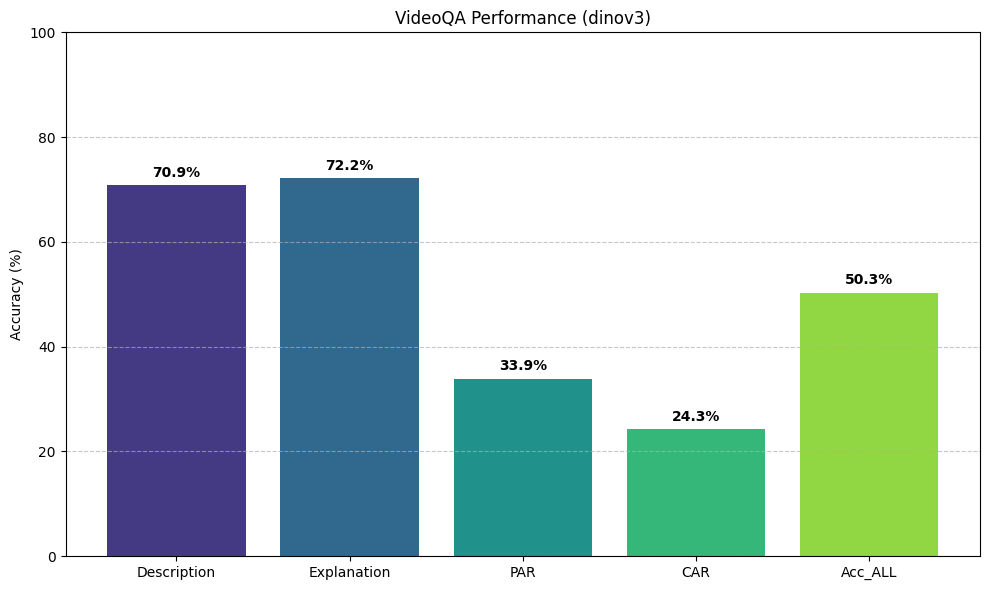

In [ ]:
# CELL 10: Detailed Evaluation with W&B Logging + CSV export per question
print('=== CELL 10: Detailed Evaluation ===')
import seaborn as sns

CSV_OUTPUT_PATH = 'test_predictions_dinov3.csv'

def _build_eval_meta_map(loader):
    dataset = getattr(loader, 'dataset', None)
    sample_list = getattr(dataset, 'sample_list', None) if dataset is not None else None
    meta_map = {}
    if sample_list is None:
        return meta_map
    for _, row in sample_list.iterrows():
        vid = str(row.get('video_id', ''))
        qtype = str(row.get('type', 'unknown'))
        qns_key = f'{vid}_{qtype}'
        meta_map[qns_key] = {
            'video_id': vid,
            'question_type': qtype,
            'question': str(row.get('question', '')),
            'answer_idx': int(row.get('answer', -1)),
            'answers': [str(row.get(f'a{i}', '')) for i in range(5)]
        }
    return meta_map


def evaluate_detailed_v2(model, loader, device, log_to_wandb=True, split_name='test', csv_output_path=CSV_OUTPUT_PATH):
    """Evaluate a split, log metrics, and export per-question CSV rows."""
    model.eval()
    type_results = {}
    prediction_rows = []
    meta_map = _build_eval_meta_map(loader)

    print("\n📊 Running Detailed Evaluation...")
    with torch.no_grad():
        for batch in tqdm(loader):
            if len(batch) == 7:
                ff, of, qns, ans_word, ans_id, qns_keys, q_family_id = batch
            else:
                ff, of, qns, ans_word, ans_id, qns_keys = batch
                q_family_id = None

            ff, of = ff.to(device), of.to(device)
            q_family_id = q_family_id.to(device) if q_family_id is not None else None

            out = model(ff, of, qns, ans_word, return_aux=True, q_family_id=q_family_id)
            if isinstance(out, dict):
                logits = out['fused_score'] if 'fused_score' in out else out['logits']
            else:
                logits = out

            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            preds = probs.argmax(axis=-1)
            targets = ans_id.numpy()
            qns_keys = list(qns_keys)

            for sample_idx, (key, pred, target, prob_vec) in enumerate(zip(qns_keys, preds, targets, probs)):
                meta = meta_map.get(str(key), {})
                video_id = str(meta.get('video_id', str(key).rsplit('_', 1)[0] if '_' in str(key) else str(key)))
                qtype = str(meta.get('question_type', str(key).rsplit('_', 1)[1] if '_' in str(key) else 'unknown'))
                question = meta.get('question', str(qns[sample_idx]) if isinstance(qns, (list, tuple)) else str(qns))
                answer_choices = meta.get('answers', [])
                if len(answer_choices) < 5:
                    answer_choices = answer_choices + [''] * (5 - len(answer_choices))
                answer_choices = answer_choices[:5]
                correct_idx = int(target)
                predicted_idx = int(pred)
                is_correct = int(predicted_idx == correct_idx)
                confidence = float(prob_vec[predicted_idx])
                predicted_answer = answer_choices[predicted_idx] if 0 <= predicted_idx < len(answer_choices) else ''
                correct_answer = answer_choices[correct_idx] if 0 <= correct_idx < len(answer_choices) else ''

                if qtype not in type_results:
                    type_results[qtype] = []
                type_results[qtype].append({
                    'video_id': video_id,
                    'pred': predicted_idx,
                    'target': correct_idx,
                    'correct': bool(is_correct)
                })

                prediction_rows.append({
                    'video_id': video_id,
                    'question_type': qtype,
                    'question': question,
                    'correct_idx': correct_idx,
                    'predicted_idx': predicted_idx,
                    'is_correct': is_correct,
                    'confidence': confidence,
                    'a0': answer_choices[0],
                    'prob_a0': float(prob_vec[0]) if len(prob_vec) > 0 else 0.0,
                    'a1': answer_choices[1],
                    'prob_a1': float(prob_vec[1]) if len(prob_vec) > 1 else 0.0,
                    'a2': answer_choices[2],
                    'prob_a2': float(prob_vec[2]) if len(prob_vec) > 2 else 0.0,
                    'a3': answer_choices[3],
                    'prob_a3': float(prob_vec[3]) if len(prob_vec) > 3 else 0.0,
                    'a4': answer_choices[4],
                    'prob_a4': float(prob_vec[4]) if len(prob_vec) > 4 else 0.0,
                    'predicted_answer': predicted_answer,
                    'correct_answer': correct_answer
                })

    # Save per-question CSV
    prediction_df = pd.DataFrame(prediction_rows)
    if not prediction_df.empty:
        prediction_df = prediction_df[[
            'video_id', 'question_type', 'question', 'correct_idx', 'predicted_idx',
            'is_correct', 'confidence', 'a0', 'prob_a0', 'a1', 'prob_a1',
            'a2', 'prob_a2', 'a3', 'prob_a3', 'a4', 'prob_a4',
            'predicted_answer', 'correct_answer'
        ]]
        prediction_df = prediction_df.sort_values(['question_type', 'video_id']).reset_index(drop=True)
        os.makedirs(os.path.dirname(csv_output_path) or '.', exist_ok=True)
        prediction_df.to_csv(csv_output_path, index=False)
        print(f'📝 Saved per-question predictions to: {csv_output_path}')
    else:
        print('⚠️ No predictions collected, CSV not created.')

    # Calculate metrics
    metrics = {}
    metrics_map = {
        'Description': 'descriptive',
        'Explanation': 'explanatory',
        'Predictive-Answer': 'predictive',
        'Predictive-Reason': 'predictive_reason',
        'Counterfactual-Answer': 'counterfactual',
        'Counterfactual-Reason': 'counterfactual_reason'
    }

    print("\n" + "=" * 60)
    print(f"EVALUATION RESULTS ({split_name.upper()})")
    print("=" * 60)

    for name, qtype in metrics_map.items():
        if qtype in type_results:
            results = type_results[qtype]
            correct = sum(1 for r in results if r['correct'])
            total = len(results)
            acc = correct / total * 100 if total > 0 else 0
        else:
            correct, total, acc = 0, 0, 0
        metrics[name] = acc
        print(f"{name:<25} ==>   {acc:.2f}%  ({correct}/{total})")

    print("-" * 60)

    def calc_hard_metric(type_ans, type_reason, name):
        if type_ans not in type_results or type_reason not in type_results:
            metrics[name] = 0
            print(f"{name:<25} ==>   0.00%  (0/0 paired)")
            return

        ans_by_vid = {r['video_id']: r['correct'] for r in type_results[type_ans]}
        reason_by_vid = {r['video_id']: r['correct'] for r in type_results[type_reason]}
        common_vids = set(ans_by_vid.keys()) & set(reason_by_vid.keys())

        both_correct = sum(1 for vid in common_vids if ans_by_vid[vid] and reason_by_vid[vid])
        total = len(common_vids)
        acc = both_correct / total * 100 if total > 0 else 0
        metrics[name] = acc
        print(f"{name:<25} ==>   {acc:.2f}%  ({both_correct}/{total} paired)")

    calc_hard_metric('predictive', 'predictive_reason', 'PAR')
    calc_hard_metric('counterfactual', 'counterfactual_reason', 'CAR')

    print("-" * 60)

    d_acc = metrics.get('Description', 0)
    e_acc = metrics.get('Explanation', 0)
    par_acc = metrics.get('PAR', 0)
    car_acc = metrics.get('CAR', 0)
    acc_all = (d_acc + e_acc + par_acc + car_acc) / 4
    metrics['Acc_ALL'] = acc_all
    print(f"{'Acc (ALL)':<25} ==>   {acc_all:.2f}%  ((D+E+PAR+CAR)/4)")
    print("=" * 60)

    if log_to_wandb:
        wandb.log({
            'eval/Description': metrics['Description'],
            'eval/Explanation': metrics['Explanation'],
            'eval/Predictive_Answer': metrics['Predictive-Answer'],
            'eval/Predictive_Reason': metrics['Predictive-Reason'],
            'eval/Counterfactual_Answer': metrics['Counterfactual-Answer'],
            'eval/Counterfactual_Reason': metrics['Counterfactual-Reason'],
            'eval/PAR': metrics['PAR'],
            'eval/CAR': metrics['CAR'],
            'eval/Acc_ALL': acc_all
        })

        wandb.run.summary['eval_Description'] = metrics['Description']
        wandb.run.summary['eval_Explanation'] = metrics['Explanation']
        wandb.run.summary['eval_PAR'] = metrics['PAR']
        wandb.run.summary['eval_CAR'] = metrics['CAR']
        wandb.run.summary['eval_Acc_ALL'] = acc_all
        wandb.run.summary['predictions_csv'] = csv_output_path
        print('📤 Metrics logged to W&B!')

    keys = ['Description', 'Explanation', 'PAR', 'CAR', 'Acc_ALL']
    values = [metrics.get(k, 0) for k in keys]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(keys, values, color=sns.color_palette('viridis', len(keys)))
    ax.set_ylim(0, 100)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'VideoQA Performance ({split_name})')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 1,
            f'{bar.get_height():.1f}%',
            ha='center',
            va='bottom',
            fontweight='bold'
        )
    plt.tight_layout()

    if log_to_wandb:
        wandb.log({'eval_chart': wandb.Image(fig)})

    chart_path = f'eval_results_{split_name}.png'
    plt.savefig(chart_path)
    plt.show()

    return metrics, type_results, csv_output_path


# Run evaluation on TEST set (has ground truth)
print('\n📌 Using TEST SET for evaluation')
metrics, raw_results, predictions_csv = evaluate_detailed_v2(model, test_loader, device, log_to_wandb=True, split_name='test', csv_output_path=CSV_OUTPUT_PATH)

In [ ]:
# CELL 11: Finish W&B Run
print('=== CELL 11: Finish W&B ===')

# Save metrics locally
with open('final_metrics_dino.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved: final_metrics_dino.json')

# Log final artifact with evaluation results
final_artifact = wandb.Artifact(
    name='final-results-dino',
    type='results',
    description='Final evaluation results and metrics (Dinov3)',
    metadata={
        'backbone': 'dinov3',
        'frame_feat_dim': FEAT_DIM,
        'best_model_artifact': BEST_ARTIFACT_NAME,
        'last_checkpoint_artifact': LAST_ARTIFACT_NAME,
        'predictions_csv': predictions_csv
    }
)
final_artifact.add_file('final_metrics_dino.json')
if os.path.exists(predictions_csv):
    final_artifact.add_file(predictions_csv)
if os.path.exists('eval_results_test.png'):
    final_artifact.add_file('eval_results_test.png')
wandb.log_artifact(final_artifact)

# Finish run
wandb.finish()
print('\n✅ W&B run finished!')
print(f'View results at: https://wandb.ai/{WANDB_ENTITY or "your-username"}/{WANDB_PROJECT}')

=== CELL 11: Finish W&B ===
Saved: final_metrics_dino.json


wandb: uploading artifact final-results-dino; updating run metadata
wandb: uploading artifact final-results-dino
wandb: uploading artifact final-results-dino; uploading output.log; uploading wandb-summary.json; uploading config.yaml; uploading media/images/eval_chart_1416_6a356f58999a89308e73.png
wandb: uploading artifact final-results-dino; uploading wandb-summary.json; uploading config.yaml; uploading media/images/eval_chart_1416_6a356f58999a89308e73.png
wandb: uploading artifact final-results-dino; uploading wandb-summary.json
wandb: uploading artifact final-results-dino; uploading history steps 1415-1416, summary, console lines 34-52
wandb: uploading artifact final-results-dino
wandb: 
wandb: Run history:
wandb:                      batch ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
wandb:                  batch_acc ▁▅▄▃▆▆▅▅▃▄▆▇▆▅█▅▆▅▆▇▅▆▇█▇▇▇▄█▇█▆█▆▄▇▆▆▇▇
wandb:                 batch_loss ▇▅▇▅█▆▄▆▃▃▃▃▆▂▅▅▁▆▄▃▅▃█▄▁▅▁▂▂▁▇▂█▁▂▅▁▄▁▁
wandb:               best_val_acc ▁▄▆▇█
wandb:          


✅ W&B run finished!
View results at: https://wandb.ai/your-username/transtr-causalvid-dino
